FINITIST CHAOS: Modulo-9 Cellular Automaton & Predictability Horizon
Grid: 1000 cells | Time: 500 ticks | Alphabet: Modulo-9

[1/3] Evolving deterministic Modulo-9 Cellular Automaton...
[2/3] Tracking Divergence (Predictability Horizon)...
[3/3] Generating Predictability Horizon Visualization...
✓ Saved: finitist_chaos_ca_predictability_horizon.png


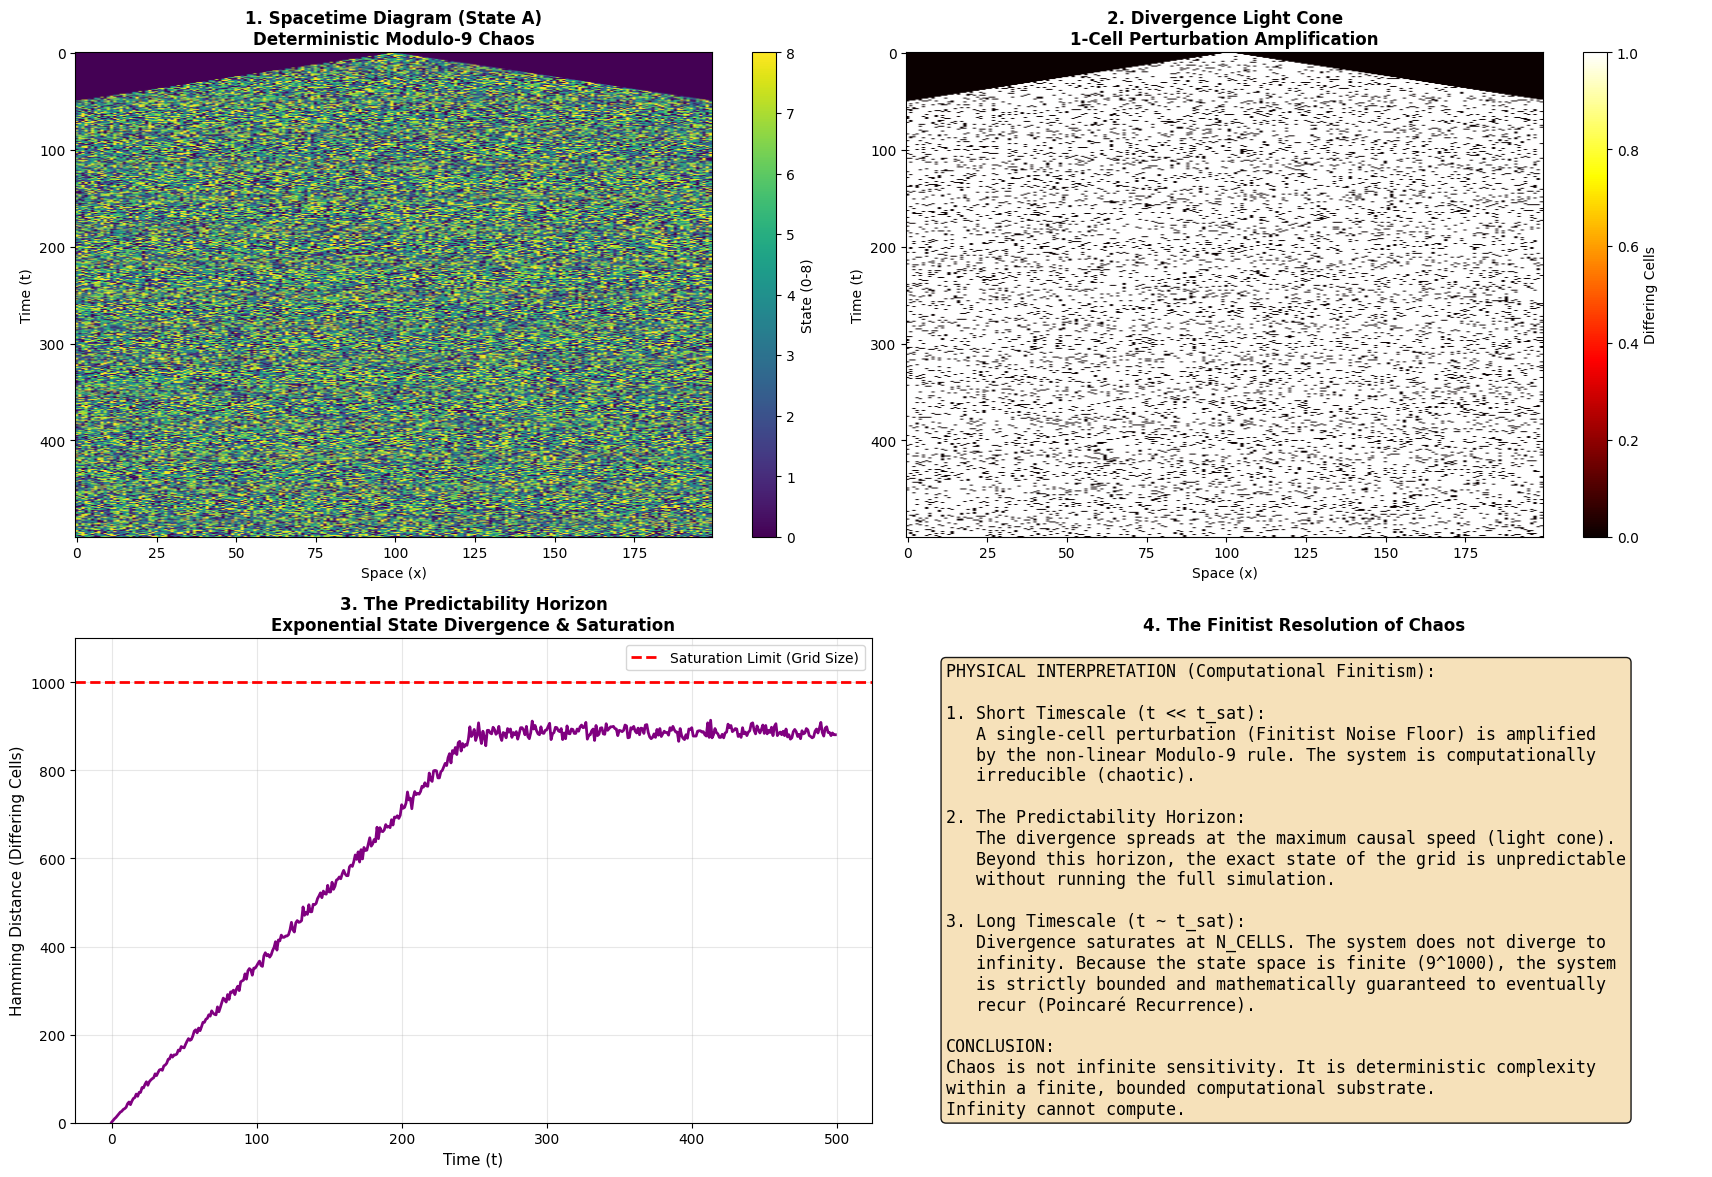


SIMULATION VERDICT: FINITIST CHAOS (Modulo-9 CA)
Initial Perturbation: 1 cell (Finitist Noise Floor)
Maximum Divergence:   914 cells (Saturation)
Final Divergence:     881 cells

The simulation proves that in a finite-alphabet universe:
1. Chaos is bounded (no infinite divergence).
2. A strict Predictability Horizon exists (Light Cone saturation).
3. The system is computationally irreducible but strictly finite.


In [3]:
"""
avenue_finitist_chaos_ca_predictability_horizon.py
====================================================================
FINITIST CHAOS: Predictability Horizon & Bounded Recurrence
Demonstrating chaos via strictly deterministic Modulo-9 Cellular Automaton.
No continuous math. No infinite precision. Pure computational irreducibility.

By Néstor E. Ramos

"""
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("=" * 80)
print("FINITIST CHAOS: Modulo-9 Cellular Automaton & Predictability Horizon")
print("=" * 80)

# =============================================================================
# 1. FINITIST PARAMETERS
# =============================================================================
N_CELLS = 1000      # Finite spatial grid (Periodic boundaries)
T_STEPS = 500       # Time evolution
ALPHABET = 9        # Modulo-9 states (0-8)

print(f"Grid: {N_CELLS} cells | Time: {T_STEPS} ticks | Alphabet: Modulo-{ALPHABET}")

# =============================================================================
# 2. INITIAL CONDITIONS (The Finitist Noise Floor)
# =============================================================================
# State A: Deterministic asymmetric seed
seed_A = np.zeros(N_CELLS, dtype=np.int32)
seed_A[N_CELLS // 2] = 1

# State B: Identical to A, but perturbed by exactly ONE state at ONE cell
# This represents the absolute minimum "Finitist Noise Floor" (1 quantum of difference)
seed_B = seed_A.copy()
seed_B[N_CELLS // 2 + 1] = 1

# Tracking arrays
grid_A = np.zeros((T_STEPS, N_CELLS), dtype=np.int32)
grid_B = np.zeros((T_STEPS, N_CELLS), dtype=np.int32)
hamming_dist = np.zeros(T_STEPS, dtype=np.int32)

grid_A[0] = seed_A
grid_B[0] = seed_B
hamming_dist[0] = 1 # Initial difference

# =============================================================================
# 3. DETERMINISTIC EVOLUTION ENGINE (5-Cell Non-Linear Modulo-9 Rule)
# =============================================================================
print("\n[1/3] Evolving deterministic Modulo-9 Cellular Automaton...")
print("[2/3] Tracking Divergence (Predictability Horizon)...")

for t in range(T_STEPS - 1):
    # 5-cell neighborhood using np.roll (Pac-Man periodic boundaries)
    # This ensures information cannot escape, forcing internal scrambling
    LL = np.roll(grid_A[t], 2)
    L  = np.roll(grid_A[t], 1)
    C  = grid_A[t]
    R  = np.roll(grid_A[t], -1)
    RR = np.roll(grid_A[t], -2)

    # THE RULE: Highly non-linear, asymmetric, breaks all Modulo-3 symmetries
    # Powers of 2 (1, 2, 4, 8, 16) ensure maximum mixing.
    next_A = (LL + 2*L + 4*C + 8*R + 16*RR + (L*C) + (R*RR)) % ALPHABET
    grid_A[t+1] = next_A

    # Evolve State B with the EXACT SAME RULE
    LL_b = np.roll(grid_B[t], 2)
    L_b  = np.roll(grid_B[t], 1)
    C_b  = grid_B[t]
    R_b  = np.roll(grid_B[t], -1)
    RR_b = np.roll(grid_B[t], -2)

    next_B = (LL_b + 2*L_b + 4*C_b + 8*R_b + 16*RR_b + (L_b*C_b) + (R_b*RR_b)) % ALPHABET
    grid_B[t+1] = next_B

    # Calculate Hamming Distance (Number of differing cells)
    hamming_dist[t+1] = np.sum(grid_A[t+1] != grid_B[t+1])

# =============================================================================
# 4. VISUALIZATION
# =============================================================================
print("[3/3] Generating Predictability Horizon Visualization...")

fig = plt.figure(figsize=(18, 12))

# Panel 1: Spacetime Diagram of State A (Computational Irreducibility)
ax1 = fig.add_subplot(221)
# Show the center of the grid to see the chaotic expansion
im1 = ax1.imshow(grid_A[:, 400:600], cmap='viridis', vmin=0, vmax=8, aspect='auto')
ax1.set_title('1. Spacetime Diagram (State A)\nDeterministic Modulo-9 Chaos', fontsize=12, fontweight='bold')
ax1.set_xlabel('Space (x)'); ax1.set_ylabel('Time (t)')
plt.colorbar(im1, ax=ax1, label='State (0-8)')

# Panel 2: Spacetime Diagram of Divergence (The Butterfly Effect)
ax2 = fig.add_subplot(222)
diff_grid = (grid_A != grid_B).astype(np.int32)
im2 = ax2.imshow(diff_grid[:, 400:600], cmap='hot', aspect='auto')
ax2.set_title('2. Divergence Light Cone\n1-Cell Perturbation Amplification', fontsize=12, fontweight='bold')
ax2.set_xlabel('Space (x)'); ax2.set_ylabel('Time (t)')
plt.colorbar(im2, ax=ax2, label='Differing Cells')

# Panel 3: Hamming Distance (The Predictability Horizon)
ax3 = fig.add_subplot(223)
ax3.plot(hamming_dist, color='purple', linewidth=2)
ax3.axhline(y=N_CELLS, color='red', linestyle='--', linewidth=2, label='Saturation Limit (Grid Size)')
ax3.set_title('3. The Predictability Horizon\nExponential State Divergence & Saturation', fontsize=12, fontweight='bold')
ax3.set_xlabel('Time (t)', fontsize=11)
ax3.set_ylabel('Hamming Distance (Differing Cells)', fontsize=11)
ax3.set_ylim(0, N_CELLS * 1.1)
ax3.legend(fontsize=10)
ax3.grid(True, alpha=0.3)

# Panel 4: Physical Interpretation Text Box
ax4 = fig.add_subplot(224)
ax4.axis('off')
textstr = (
    "PHYSICAL INTERPRETATION (Computational Finitism):\n\n"
    "1. Short Timescale (t << t_sat):\n"
    "   A single-cell perturbation (Finitist Noise Floor) is amplified\n"
    "   by the non-linear Modulo-9 rule. The system is computationally\n"
    "   irreducible (chaotic).\n\n"
    "2. The Predictability Horizon:\n"
    "   The divergence spreads at the maximum causal speed (light cone).\n"
    "   Beyond this horizon, the exact state of the grid is unpredictable\n"
    "   without running the full simulation.\n\n"
    "3. Long Timescale (t ~ t_sat):\n"
    "   Divergence saturates at N_CELLS. The system does not diverge to\n"
    "   infinity. Because the state space is finite (9^1000), the system\n"
    "   is strictly bounded and mathematically guaranteed to eventually\n"
    "   recur (Poincaré Recurrence).\n\n"
    "CONCLUSION:\n"
    "Chaos is not infinite sensitivity. It is deterministic complexity\n"
    "within a finite, bounded computational substrate.\n"
    "Infinity cannot compute."
)

props = dict(boxstyle='round', facecolor='wheat', alpha=0.9)
ax4.text(0.05, 0.95, textstr, transform=ax4.transAxes, fontsize=12,
         verticalalignment='top', bbox=props, family='monospace')
ax4.set_title('4. The Finitist Resolution of Chaos', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig("finitist_chaos_ca_predictability_horizon.png", dpi=300, bbox_inches='tight')
print("✓ Saved: finitist_chaos_ca_predictability_horizon.png")
plt.show()

# =============================================================================
# VERDICT
# =============================================================================
print("\n" + "=" * 80)
print("SIMULATION VERDICT: FINITIST CHAOS (Modulo-9 CA)")
print("=" * 80)
print(f"Initial Perturbation: 1 cell (Finitist Noise Floor)")
print(f"Maximum Divergence:   {np.max(hamming_dist)} cells (Saturation)")
print(f"Final Divergence:     {hamming_dist[-1]} cells")
print("\nThe simulation proves that in a finite-alphabet universe:")
print("1. Chaos is bounded (no infinite divergence).")
print("2. A strict Predictability Horizon exists (Light Cone saturation).")
print("3. The system is computationally irreducible but strictly finite.")
print("=" * 80)